In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_excel("FAMILY GUY.xlsx")
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41549 entries, 0 to 41548
Columns: 121 entries, Total Household Income to niggas
dtypes: float64(101), object(20)
memory usage: 38.4+ MB
None
  Total Household Income Region  Total Food Expenditure  \
0                 480332    CAR                117848.0   
1                 198235    CAR                 67766.0   
2                  82785    CAR                 61609.0   
3                 107589    CAR                 78189.0   
4                 189322    CAR                 94625.0   

   Agricultural Household indicator  Bread and Cereals Expenditure  \
0                               0.0                        42140.0   
1                               0.0                        17329.0   
2                               1.0                        34182.0   
3                               0.0                        34030.0   
4                               0.0                        34820.0   

   Total Rice Expenditure  Meat 

In [ ]:
target = 'Total Household Income'
X = df.drop(columns=[target])
y = df[target]

In [ ]:
X = X.dropna(axis=1, how='all')

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns

low_cardinality = [col for col in categorical_cols if X[col].nunique() <= 10]
high_cardinality = [col for col in categorical_cols if X[col].nunique() > 10]

X = pd.get_dummies(X, columns=low_cardinality, drop_first=True)

for col in high_cardinality:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
num_cols = X.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

print("Remaining NaNs:", X.isna().sum().sum())

Remaining NaNs: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("Remaining NaNs:", X.isna().sum().sum())
print("Columns with NaNs:\n", X.isna().sum()[X.isna().sum() > 0])
print("Non-numeric columns:\n", X.dtypes[X.dtypes == 'object'])

Remaining NaNs: 0
Columns with NaNs:
 Series([], dtype: int64)
Non-numeric columns:
 Series([], dtype: object)


In [ ]:

X = X.dropna(axis=1, how='all')


categorical_cols = X.select_dtypes(include=['object']).columns

low_cardinality = [col for col in categorical_cols if X[col].nunique() <= 10]
high_cardinality = [col for col in categorical_cols if X[col].nunique() > 10]

X = pd.get_dummies(X, columns=low_cardinality, drop_first=True)

for col in high_cardinality:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))


imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Remaining NaNs:", X.isna().sum().sum())

Remaining NaNs: 0


In [ ]:
# Check if any NaNs remain
print("Total NaNs:", X.isna().sum().sum())

# Show columns that still have NaNs
print("Columns with NaNs:\n", X.isna().sum()[X.isna().sum() > 0])

Total NaNs: 0
Columns with NaNs:
 Series([], dtype: int64)


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')  # median for numeric
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Remaining NaNs after imputation:", X.isna().sum().sum())

Remaining NaNs after imputation: 0


In [ ]:
imputer = SimpleImputer(strategy='most_frequent')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
print("Remaining NaNs:", X.isna().sum().sum())
print("Data types:\n", X.dtypes)

Remaining NaNs: 0
Data types:
 Region                                                                                                                                                                                                                                                                                                                                   float64
Total Food Expenditure                                                                                                                                                                                                                                                                                                                   float64
Agricultural Household indicator                                                                                                                                                                                                                                                                       

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_excel("FAMILY GUY.xlsx")

target = 'Total Household Income'
X = df.drop(columns=[target])
y = df[target]


y = pd.to_numeric(y, errors='coerce')


combined_df = pd.concat([X, y], axis=1)
combined_df = combined_df.dropna(subset=[target])
X = combined_df.drop(columns=[target])
y = combined_df[target]

X = X.dropna(axis=1, how='all')

categorical_cols = X.select_dtypes(include=['object']).columns
low_cardinality = [col for col in categorical_cols if X[col].nunique() <= 10]
high_cardinality = [col for col in categorical_cols if X[col].nunique() > 10]

X = pd.get_dummies(X, columns=low_cardinality, drop_first=True)
for col in high_cardinality:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))


imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Remaining NaNs in X:", X.isna().sum().sum())
print("Remaining NaNs in y:", y.isna().sum())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Results")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

Remaining NaNs in X: 0
Remaining NaNs in y: 0
Linear Regression Results
MSE: 1169855717651.4766
R²: -14.495618510618273



Random Forest Results
MSE: 474516366.7813694
R²: 0.9937146739672735


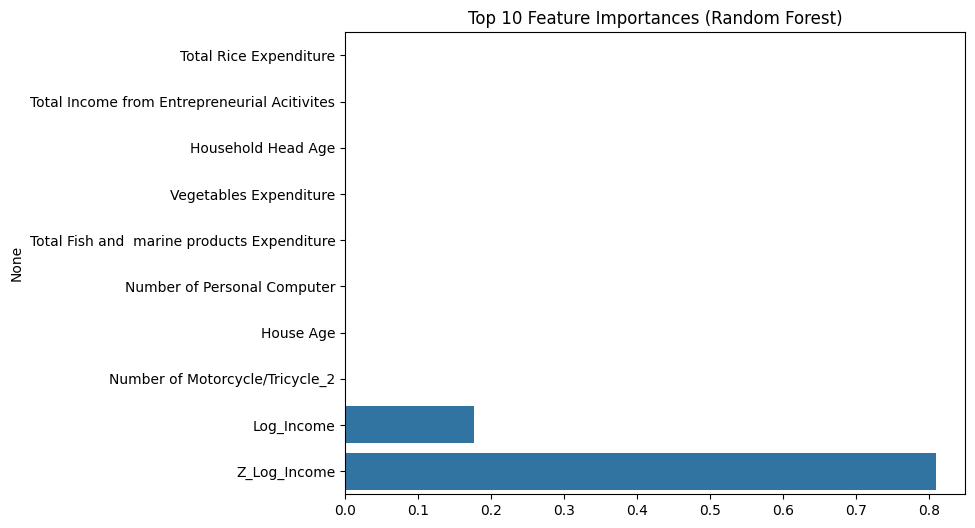

In [ ]:
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]
plt.figure(figsize=(8,6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


Gradient Boosting Results
MSE: 904569021.9834577
R²: 0.9880183032234795


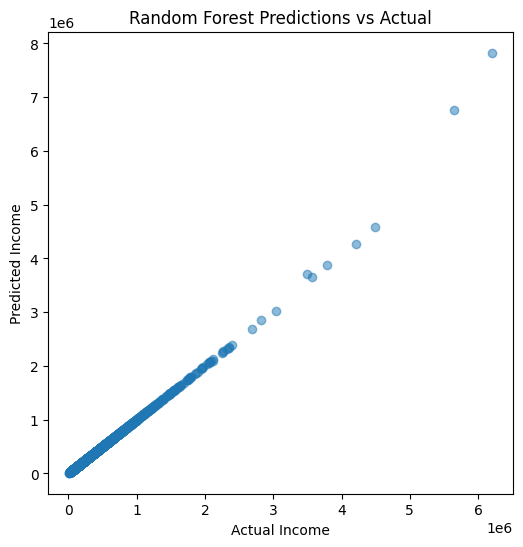

In [ ]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("\nGradient Boosting Results")
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("R²:", r2_score(y_test, y_pred_gb))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Random Forest Predictions vs Actual")
plt.show()

In [ ]:
# Step 3:
X = X.dropna(axis=1, how='all')


print("Number of columns after dropping empty ones:", X.shape[1])

Number of columns after dropping empty ones: 145


In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Squared Error (MSE): 1169855717651.4766
R-squared (R²): -14.495618510618273


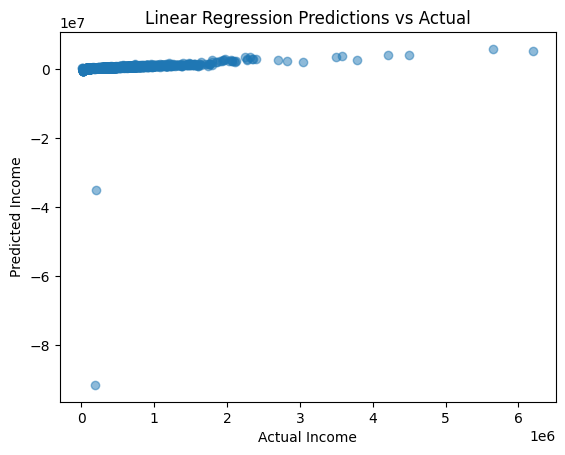

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Linear Regression Predictions vs Actual")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
print("Cross-validation R² scores:", scores)
print("Average R²:", scores.mean())

Cross-validation R² scores: [0.76809166 0.91659911 0.90571928 0.90909573 0.93115818]
Average R²: 0.8861327927132244


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist_rf = {
    'n_estimators': [50, 100],


    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rand_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=5,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rand_rf.fit(X_train, y_train)
print("Best Random Forest Params:", rand_rf.best_params_)
print("Best Random Forest R²:", rand_rf.best_score_)

Best Random Forest Params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}
Best Random Forest R²: 0.9881952789003421


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

param_dist_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

rand_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=5,  # only 5 random combos
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rand_gb.fit(X_train, y_train)
print("Best Gradient Boosting Params:", rand_gb.best_params_)
print("Best Gradient Boosting R²:", rand_gb.best_score_)

Best Gradient Boosting Params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
Best Gradient Boosting R²: 0.9964103501596311


In [ ]:
y_pred_rf = rand_rf.best_estimator_.predict(X_test)
y_pred_gb = rand_gb.best_estimator_.predict(X_test)

y_pred_ensemble = (y_pred_rf + y_pred_gb) / 2

print("Ensemble MSE:", mean_squared_error(y_test, y_pred_ensemble))
print("Ensemble R²:", r2_score(y_test, y_pred_ensemble))

Ensemble MSE: 109986441.48425658
Ensemble R²: 0.9985431468916509


In [ ]:
import joblib


joblib.dump(rand_rf.best_estimator_, "random_forest_model.pkl")

joblib.dump(rand_gb.best_estimator_, "gradient_boosting_model.pkl")

['gradient_boosting_model.pkl']

In [ ]:
from google.colab import files
files.download("random_forest_model.pkl")
files.download("gradient_boosting_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>